In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from msfm.utils import prior, parameters, files, logger, observation, scales
from msi.utils import preprocessing

# import tensorflow as tf
# tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)
# from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
# from msi.gaussian_mixture import architecture
# from deep_lss.utils import configuration

# from msi.flow_conductor import architecture
# from msi.flow_conductor.likelihood_flow import LikelihoodFlow

In [3]:
use_flow = False

if use_flow:
    import torch
    from msi.flow_conductor.likelihood_flow import LikelihoodFlow
    from msi.flow_conductor import architecture
else:
    import tensorflow as tf
    from msi.gaussian_mixture.likelihood_gmm import LikelihoodGMM
    from msi.gaussian_mixture import architecture

### v10

In [4]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

In [5]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg", "n_bg"]

In [6]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

In [7]:
# # conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
# # out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v10/cls"

# n_params = len(params)
# apply_log = True
# standardize = False
# pca_components = None
# # n_steps = 50_000
# n_steps = 100_000
# cosine_decay = False
# # cosine_decay = True

# # label = f"lensing={with_lensing},clustering={with_clustering},log={apply_log},standard={standardize},pca={pca_components},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}"

# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"

# # file_label = "high_noise"
# # file_label = "no_noise"
# # file_label = "legacy"
# # file_label = "legacy,fixed_binning"
# # file_label = "legacy,l_min=0"
# # file_label = "high_noise"
# # file_label = "no_ell_in_bins_[0,10]"
# # file_label = "no_ell_in_bins_[:8]"
# # file_label = "no_ell_in_bins_[:2]"
# # file_label = "no_ell_in_bins_[-8:]"
# # file_label = "standard"
# # file_label = "legacy,corrected"
# # file_label = "legacy,corrected,l_min"
# # file_label = "default,1%noise"
# # file_label = "10%noise"
# # file_label = "default"
# # file_label = "default,1%noise"
# # file_label = "default,10%noise"
# # file_label = "default,naive_noise"
# # file_label = "sanity_check_2"
# # file_label = "default,from_maps"

# # file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# # file_label += "octant"

# # file_label = "default,new"

# # file_label = "z_consistency,auto"
# # file_label = "z_consistency,26"
# # file_label = "z_consistency,30"
# # file_label = "z_consistency,33"
# # file_label = "z_consistency,35"

# # file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# file_label = "28mpc"
# file_label += "_flock"
# # file_label += "_octant"

# # file_label = "hard_cut"
# # file_label = "smoothing_big,noise_small"
# # file_label = "smoothing_small,noise_big"

# label = os.path.join(label, file_label)
# loss = "mutual_info"
# pred_file = os.path.join(out_dir, loss, label, "preds.h5")

### v11

In [8]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

In [9]:
with_lensing = False
with_clustering = True
params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [10]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

In [11]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v11/extended"
out_dir = "/pscratch/sd/a/athomsen/run_files/v11/cls"

n_params = len(params)
apply_log = True
standardize = False
pca_components = None
# n_steps = 50_000
n_steps = 100_000
cosine_decay = False

label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"

# file_label = "16mpc"
# file_label = "20mpc"
# file_label = "24mpc"
file_label = "28mpc"
# file_label += "octant"

label = os.path.join(label, file_label)
loss = "mutual_info"

pred_file = os.path.join(out_dir, loss, label, "preds.h5")

# load predictions

In [12]:
def try_mock(f, mock):
    try:
        pred = f[f"mocks/{mock}"][:]
        print(f"Read {mock} predictions")
        
        return pred
    except:
        print(f"There is no {mock} mock in the file")
        
with h5py.File(pred_file, "r") as f:
    grid_preds = f["grid/preds/test"][:]
    grid_cosmos = f["grid/cosmos/test"][:]
    fidu_preds = f["fidu/preds"][:]
    
    buzzard_pred = try_mock(f, "Buzzard")
    buzzard_pred_dnf = try_mock(f, "Buzzard_mocked_DNF")
    cardinal_pred = try_mock(f, "Cardinal")
    
    mice_pred = try_mock(f, "MICE")
    euclid_pred = try_mock(f, "Euclid")
    
print(f"Read from {pred_file}")

Read Buzzard predictions
There is no Buzzard_mocked_DNF mock in the file
Read Cardinal predictions
There is no MICE mock in the file
There is no Euclid mock in the file
Read from /pscratch/sd/a/athomsen/run_files/v11/cls/mutual_info/lensing=False,clustering=True,standard=False,cosine=False,steps=100000/28mpc/preds.h5


# normalizing flow

### initialization

In [13]:
# # input dimensions
# x_dim = grid_preds.shape[-1]
# theta_dim = grid_cosmos.shape[-1]

# # shared hyperparameters
# context_embedding_dim = 32

# embedding_net = architecture.get_context_embedding_net(
#     context_dim=theta_dim,
#     context_embedding_dim=context_embedding_dim,
#     hidden_dim=64,
#     n_blocks=3,
#     dropout_probability=0.0,
#     use_batch_norm=False,
# )    

# base_dist = architecture.get_normal_dist(
#     feature_dim=x_dim,
# )

# transform = architecture.get_sigmoids_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=4,
#     hidden_dim=256,
#     svd_kwargs={},
#     sigmoids_kwargs={
#         "n_sigmoids": 32,
#         "num_blocks": 3,
#         "dropout_probability": 0.0,
#     }
# )

# # transform = architecture.get_lipschitz_transform(
# #     feature_dim=x_dim,
# #     context_embedding_dim=context_embedding_dim,
# #     n_layers=5,
# #     hidden_dim=128,
# # )

# model = LikelihoodFlow(
#     params, 
#     conf, 
#     embedding_net=embedding_net,
#     base_dist=base_dist,
#     transform=transform,
#     # out_dir=out_dir, 
#     label=label,
#     # label=label + "_longer_chain",
#     # label=label + "_longer_training",
#     # label=label + "_training_1",
#     load_existing=False,
#     # load_existing=True,
# )

### training

In [14]:
# # default
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [15]:
# # underfit
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=10,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

# Gaussian Mixture Model

In [16]:
layers = architecture.get_gmm_layers(
    n_x=grid_preds.shape[-1],
    n_theta=grid_cosmos.shape[1],
    n_gaussians=1,
    n_units=256,
    n_layers=8,
    activation="relu",
    dropout_rate=0.1,
)

model = LikelihoodGMM(
    params, 
    conf,
    layers=layers,
    out_dir=out_dir, 
    label=label,
    load_existing=True,
    # load_existing=False,
)

24-11-04 14:32:40 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=False,clustering=True,standard=False,cosine=False,steps=100000/28mpc/likelihood_gmm 
24-11-04 14:32:40 likelihood_g INF   Loaded the model from /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=False,clustering=True,standard=False,cosine=False,steps=100000/28mpc/likelihood_gmm 


In [17]:
# # n_cosmos = file_dict["grid/pred"].shape[0]
# # n_examples = grid_preds.shape[0]
# # # such that GPU utilization is maximized, but not larger
# # batch_size = 8 * n_cosmos
# # print(f"batch_size = {batch_size} for {n_examples / batch_size} steps per epoch")
# batch_size = 10_000

# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=1_000,
#     # dataset
#     batch_size=batch_size,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # schedule
#     # scheduler_kwargs={"factor": 0.75, "patience": 20, "cooldown": 10, "min_lr": 1e-6},
#     scheduler_kwargs={"factor": 0.8, "patience": 10, "cooldown": 5, "min_lr": 1e-6},
#     # scheduler_kwargs={},
#     # early stopping
#     n_patience_epochs=100,
#     min_delta=1e-5,
#     save_model=True,
# )

### convergence tests

In [18]:
# # v11 and v12
# n_examples = 1000
# _ = model.plot_diagnostics_exp(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=grid_cosmos,
#     n_samples=100,
#     do_hist=False,
#     do_dlss=False,
#     do_eecp=False,
#     do_tarp=False,
# )

# $\leq$ v10

In [19]:
# # this only works for v10
# unique_cosmos, inverse_indices = np.unique(grid_cosmos, axis=0, return_inverse=True)
# n_unique_cosmos = unique_cosmos.shape[0]
# n_examples_per_cosmo = int(grid_cosmos.shape[0]//n_unique_cosmos)

# grid_preds_per_cosmo = np.zeros((n_unique_cosmos, n_examples_per_cosmo, grid_preds.shape[1]))
# for i, unique_val in tqdm(enumerate(unique_cosmos)):
#     matching_indices = np.where(inverse_indices == i)[0]
#     grid_preds_per_cosmo[i, :len(matching_indices)] = grid_preds[matching_indices]

# _ = model.plot_diagnostics(
#     # shape (n_cosmos, n_examples_per_cosmo, n_summary)
#     grid_preds_true=grid_preds_per_cosmo,
#     # shape (n_cosmos, n_summary)
#     grid_cosmos=unique_cosmos,
#     n_samples=100,
#     # do_hist=False,
#     # do_dlss=False,
#     do_eecp=False,
#     # do_tarp=False,
# )

# $\geq$ v11

24-11-04 14:32:41 likelihood_b WAR   grid_preds_true.shape = (200000, 7), for sobol sequence + latin hypercube sampling 
24-11-04 14:32:41 likelihood_b INF   Selecting 10000 random cosmologies 
24-11-04 14:32:41 likelihood_b INF   Drawing samples from the likelihood 
100%|████████████████████████████|   | 1/1 [00:01<00:00,  1.27s/it]           drawing samples with batch_size=10000
24-11-04 14:32:42 likelihood_b INF   Done drawing samples after 0:00:01.33 
100%|████████████████████████████|   | 10000/10000 [00:00<00:00, 113564.60it/s] EECP: looping through cosmos
24-11-04 14:32:44 diagnostics. INF   TARP random reference points: Using the default 
24-11-04 14:32:44 diagnostics. INF   TARP uncertainty from 100 bootstrap samples 


100%|██████████| 100/100 [00:05<00:00, 16.78it/s]


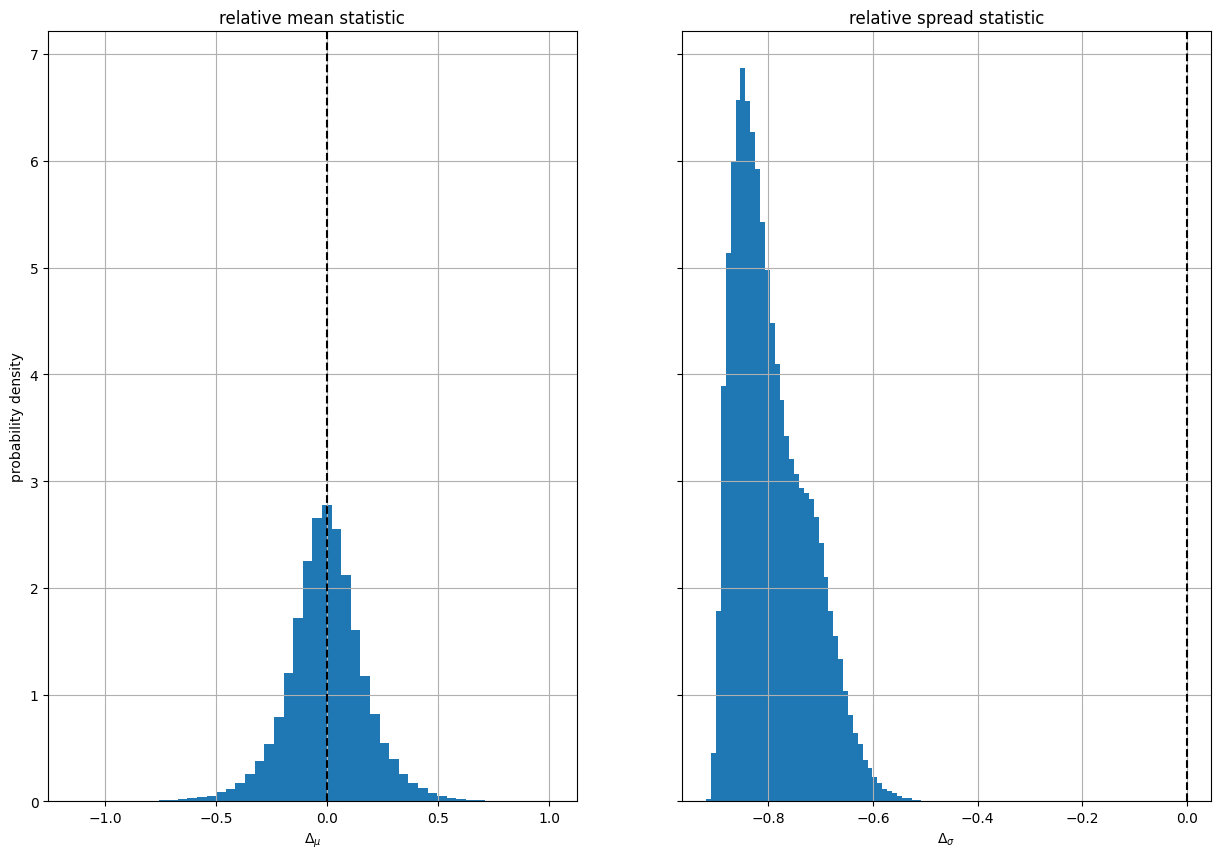

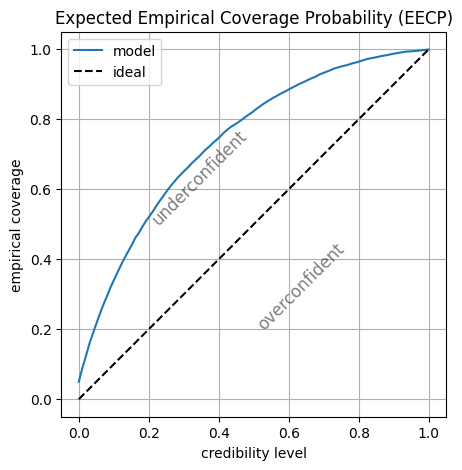

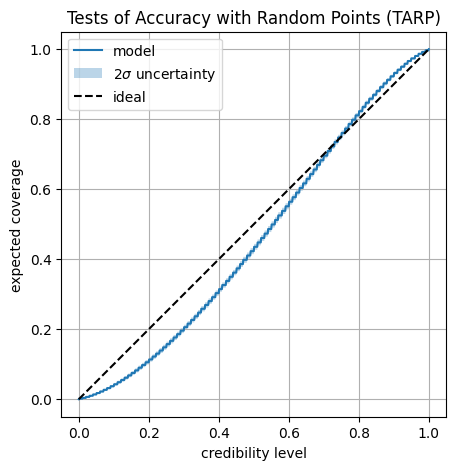

In [20]:
_ = model.plot_diagnostics(
    # these must be the raw arrays where the cosmo and example axis are still separate
    grid_preds_true=grid_preds, 
    grid_cosmos=grid_cosmos,
    n_cosmos=10_000,
    n_samples=100,
    do_hist=False,
    # do_dlss=False,
    # do_eecp=False,
    # do_tarp=False,
)